### $\color{indianred}{\text{ASTROSTATISTIKA - v3}} $

<hr style="border: none; height: 2px; background-color: indianred; opacity: 0.5;" />

In [154]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"text.usetex": False, "font.size" : 10, "font.family": "monospace"})
import seaborn as sns
from numpy import random
from numpy.random import multinomial
from scipy.special import erf
from scipy.stats import uniform, norm, laplace, poisson, binom, cauchy, gamma, cosine, lognorm, skew, kurtosis, gaussian_kde, mode, expon
from scipy.stats import t as student_t
from scipy.stats import f as fisher_f
from scipy.stats import weibull_min
from tqdm import tqdm

Generisanje slučajnih brojeva ne može odrađeno u realnosti (računari su suštinski *determinističke* mašine). Jedan od načina je da se npr. uzorkuje

iz nekog intrinzički *random* prirodnog procesa, pa da se koriste ti brojevi. Nama je važno da su procesi reproducibilni (pravimo funkcije raspodjele), 

te se koristi `seed`.

In [169]:
np.random.seed(123)
print(np.random.random(3))

np.random.seed(123)
print(np.random.random(3))

[0.69646919 0.28613933 0.22685145]
[0.69646919 0.28613933 0.22685145]


Postoji veliki broj jednoparametarskih raspodjela, ali srećom, svega desetak je dovoljno da se opiše većinski dio praktičnih primjena u astronomiji 

i astrofizici. Jednoparametarske (funkcije) raspodjele opisuju vjerovatnoću da slučajna varijabla $x$ uzme neku vrijednost.

$\bigstar$ ( i )  **Uniformna raspodjela** može se opisati jednačinom ispod:

$$
p(x\,|\,\mu, W) = \begin{cases} \frac{1}{W},\, & |x - \mu| \leq \frac{W}{2} \\ 0,\, & \text{inače} \end{cases}
$$

Medijana i srednja vrijednost su jednake $\mu$. Svaka tačka unutar neprekidnog opsjega $W$ ima istu šansu za *pojavljivanjem*, te otud *top-hat* oblik. 

Pošto oblik raspodjele ne zavisi od  mijenjanja lokacije duž $x$-ose ili množenja $x$ skalarom, može se definisati $z=\frac{x-\mu}{W}$, te onda imamo:

$$
p(z) = \begin{cases} 1,\, & |z| \leq \frac{1}{2} \\ 0,\, & |z| > \frac{1}{2} \end{cases}
$$

Uniformna raspodjela se često pojavljuje, npr. kao raspodjela pozicije fotona detektovanih pikselom konačne veličine. Tu je poznat rezultat:

$$
\sigma=\frac{W}{\sqrt{12}}.
$$

In [137]:
dist =  uniform(0, 5) 
r = dist.rvs(10) 
print(r)
p = dist.pdf(1)
print(p) 

[2.42576696 4.40434872 2.80830185 0.74185657 4.86899668 4.08554
 4.27954042 4.50313022 3.38532824 1.03049416]
0.2


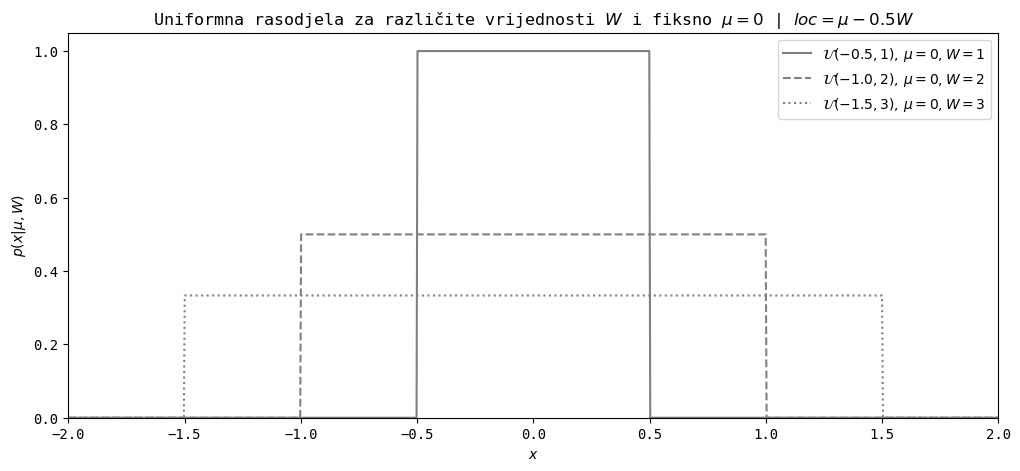

In [129]:
x = np.linspace(-2, 2, 1000)
u1 = uniform(-0.5, 1) # loc = μ - W/2 (lijeva granica), scale = W (širina intervala)  
u2 = uniform(-1.0, 2)  
u3 = uniform(-1.5, 3)   
plt.figure(figsize=(12, 5))
plt.plot(x, u1.pdf(x), label=r'$\mathcal{U}(-0.5,1),\,\mu=0, W=1$', color='grey', ls='-')
plt.plot(x, u2.pdf(x), label=r'$\mathcal{U}(-1.0,2),\,\mu=0, W=2$', color='grey', ls='--')
plt.plot(x, u3.pdf(x), label=r'$\mathcal{U}(-1.5,3),\,\mu=0, W=3$', color='grey', ls=':')
plt.xlim(-2, 2)
plt.ylim(0, 1.05)
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x|\mu, W)$')
plt.title('Uniformna rasodjela za različite vrijednosti $W$ i fiksno $\mu=0$ | $loc=\mu-0.5 W$')
plt.legend()
plt.show()

$\bigstar$ ( ii )  **Normalna raspodjela** prikazuje se jednačinom: 

$$
p(x|\mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}} e^{\frac{-(x-\mu)^2}{2\sigma^2}},
$$

gdje je $\mu$ srednja vrijednost, a $\sigma$ standardno odstupanje. Postoji i notacija gdje se koristi $\mathcal{N}(\mu,\sigma^2)$, ali mi koristimo $\mathcal{N}(\mu,\sigma)$.

Normalna raspodjela ima dva glavna svojstva. Prvo, konvolucija dvije normalne raspodjele je isto normalna raspodjela. Konvolucija $f(x)$ sa $g(x)$ jeste:

$$
(f \star g)(x) = \int_{-\infty}^{\infty} f(x')\, g(x - x')\, dx' = \int_{-\infty}^{\infty} f(x - x')\, g(x')\, dx'.
$$

Konvolucija neke raspodjele koju želimo da izmjerimo, $\mathcal{N}(\mu_0,\sigma_0)$, sa raspodjelom $\mathcal{N}(b,\sigma_e)$ daje $\mathcal{N}(\mu_c,\sigma_c)$, gdje su $\mu_c=\mu_0+b$ i $\sigma_c=\sqrt{\sigma_0^2+\sigma_e^2}$.

Dakle, da pojasnimo, $\mathcal{N}(\mu_0,\sigma_0)$ je intrinzična raspodjela izvora, $\mathcal{N}(b,\sigma_e)$ opisuje grešku instrumenta ($b$ - pristrasnost). Posmatrano je $\mathcal{N}(\mu_c,\sigma_c)$. Za

pronalaženje $\mu_0,\sigma_0$ potrebno je dobro znati $b,\sigma_e$. Konvolucija dva gausijana daje validan *PDF*, a za množenje to ne važi. Drugo glavno svojstvo $\mathcal{N}$ jeste 

da je Furijeov transform gausijana isto gausijan (ispod je data definicija, pa onda primjer od interesa):

$$
H(f) = \int_{-\infty}^{\infty} h(t)\, e^{-i2\pi ft}\, dt,\,\,h(t) = \int_{-\infty}^{\infty} H(f)\, e^{i2\pi ft}\, df,
$$

$$
H_{\text{G}}(f) = e^{-2\pi^2\sigma^2 f^2}\left[\cos(2\pi f\mu) + i\sin(2\pi f\mu)\right].
$$

Kumulativna funkcija raspodjele je data kao:

$$
P(x\,|\,\mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}} \int_{-\infty}^{x} e^{\frac{-(x'-\mu)^2}{2\sigma^2}} dx',
$$

ali obično se predstavlja funkcijom greške:

$$
\text{erf}(z) = \frac{2}{\sqrt{\pi}} \int_0^z e^{-t^2} dt,\,\,\text{erf}(\infty)=1,
$$

te se može pisati:

$$
P(x\,|\,\mu, \sigma) = \frac{1}{2}\left(1 \pm \,\text{erf}\left(\frac{|x-\mu|}{\sigma\sqrt{2}}\right)\right),
$$

gdje se "+" znak uzima za $x>\mu$. Takođe, generalno važi (za podatke generisane iz $\mathcal{N}$) da se $68\%$ podataka nalazi na $1\sigma$, $95\%$ na $2\sigma$ i $\sim99\%$ na $3\sigma$ od $\mu$.

Interkvartilni opsjeg se može iskazati kao:

$$
q_{75}-q_{25}=\sigma2\sqrt{2}\text{erf}^{-1}(0.5)\approx1.349\sigma.
$$

Dodatno, ukoliko $x$ prati normalnu raspodjelu, onda $y=e^x$ prati tzv. log-normalnu raspodjelu. Srednja vrijednost prati $e^{\mu+\sigma^2/2}$, mod $e^{\mu-\sigma^2}$ i medijana $e^\mu$.

In [171]:
dist = norm(0, 1) 
r = dist.rvs(10) 
print(r)
p = dist.pdf(0) 
print(p) 

erf(1) # erf

print(dist.cdf(-3), dist.cdf(0), dist.cdf(3)) # cdf
print(dist.ppf(q=0.025), dist.ppf(q=0.5), dist.ppf(q=0.975)) # kvantili

[-0.14337247 -0.6191909  -0.76943347  0.57674602  0.12652592 -1.30148897
  2.20742744  0.52274247  0.46564476  0.72491523]
0.3989422804014327
0.0013498980316300933 0.5 0.9986501019683699
-1.9599639845400545 0.0 1.959963984540054


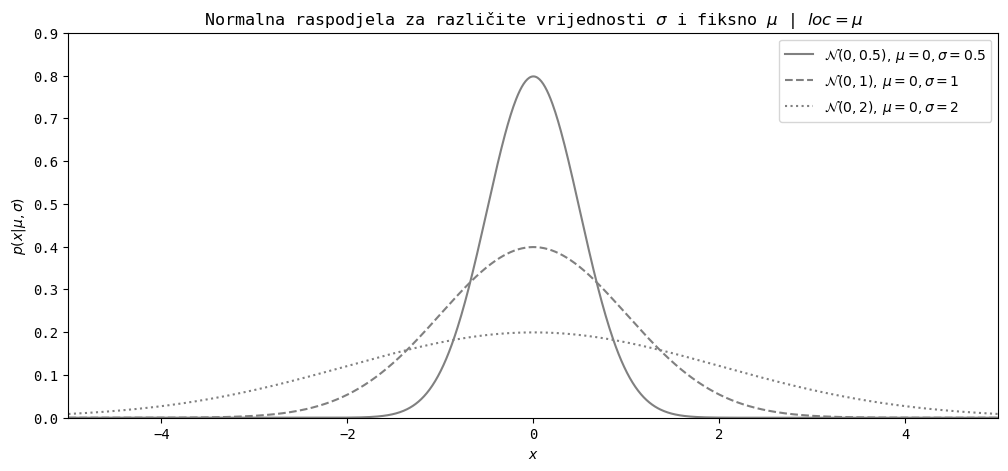

In [145]:
x = np.linspace(-5, 5, 1000)
g1 = norm(0, 0.5) 
g2 = norm(0, 1)  
g3 = norm(0, 2) 
plt.figure(figsize=(12, 5))
plt.plot(x, g1.pdf(x), label=r'$\mathcal{N}(0,0.5),\,\mu=0, \sigma=0.5$', color='grey', ls='-')
plt.plot(x, g2.pdf(x), label=r'$\mathcal{N}(0,1),\,\mu=0, \sigma=1$', color='grey', ls='--')
plt.plot(x, g3.pdf(x), label=r'$\mathcal{N}(0,2),\,\mu=0, \sigma=2$', color='grey', ls=':')
plt.xlim(-5, 5)
plt.ylim(0, 0.9)
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x|\mu, \sigma)$')
plt.title('Normalna raspodjela za različite vrijednosti $\sigma$ i fiksno $\mu$ | $loc=\mu$')
plt.legend()
plt.show()  

$\bigstar$ ( iii )  **Binomna raspodjela** prikazuje se jednačinom: 

$$
p(k\,|\,b, N) = \frac{N!}{k!(N-k)!} b^k (1-b)^{N-k},
$$

i ona opisuje raspodjelu diskretne varijable koja može poprimiti samo dvije vrijednosti (npr. neki događaj se dešava ili ne dešava). Definisano je $b$ kao 

vjerovatnoća uspjeha, a raspodjela diskretne varijable $k\in\Z$ mjeri koliko ima uspjeha za $N$ pokušaja. Specijalan slučaj za $N=1$ zove se Bernulijeva

raspodjela. Srednja vrijednost za binomnu raspodjelu je $\overline{k}=bN$ i standardna devijacija je $\sigma_k=\sqrt{Nb(1-b)}$.

Proces koji prati binomnu raspodjelu jeste bacanje novčića. Ukoliko je novčić fer, onda je $b=0.5$. Za $N$ bacanja, sa $k$ uspjeha, postavlja se pitanje šta

je neko $b^0$ (najbolja procjena $b$), i šta je njegova neodređenost $\sigma_b$. Za veliko $N$, važi $b^0=k/N$ i $\sigma_b=\sigma_k/N$. Pretpostavka je da je raspodjela prave

vrijednosti $b$ data kao $\mathcal{N}(b^0,\sigma_b)$. Obično je potrebno $10^4$ bacanja da bi se dobilo $b=0.500\pm0.005$.

Generalizacija binomne raspodjele je multinomijalna raspodjela. Varijabla može imati $M$ diskretnih vrijednosti, sa različitim vjerovatnoćama $b_m$.


In [151]:
dist = binom(20, 0.7) # N, b
r = dist.rvs(10) 
print(r)
p = dist.pmf(8) # dakle, ne pdf
print(p)

vals = multinomial(10 , pvals =[0.2, 0.3 , 0.5])
print(vals)

[15 15 15 14 14 11 15 16 13 15]
0.003859281930901185
[2 5 3]


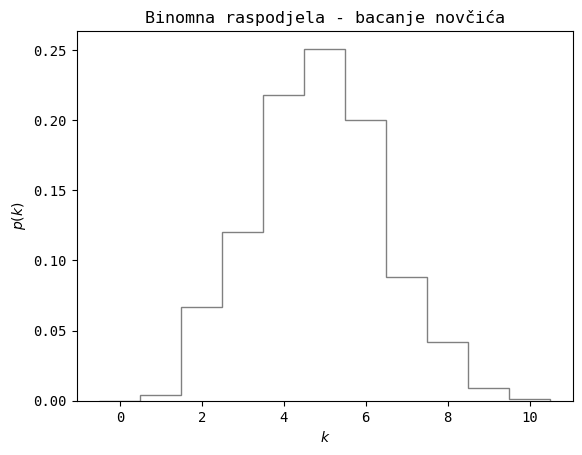

In [199]:
novcic = binom.rvs(n=10, p=0.5, size=1000) # bacanja, vjerovatnoća (G), broj ponavljanja eksperimenta
# novcic je jedan br. (koliko puta je pala glava u n bacanja, za m izvođenja eksperimenta)
plt.hist(novcic, bins=np.arange(-0.5, 11.5, 1), histtype='step', density=True, color='grey')
plt.xlabel(r'$k$')
plt.ylabel(r'$p(k)$')
plt.title('Binomna raspodjela - bacanje novčića')
plt.show()

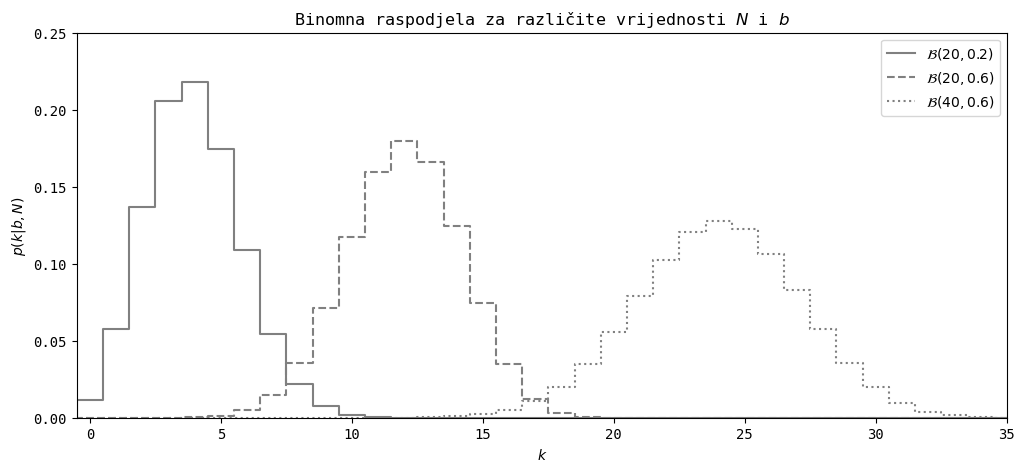

In [152]:
k = np.arange(-1, 200)
b1 = binom(20, 0.2)
b2 = binom(20, 0.6)
b3 = binom(40, 0.6)

plt.figure(figsize=(12, 5))
plt.plot(k, b1.pmf(k), label=r'$\mathcal{B}(20,0.2)$', color='grey', ls='-', drawstyle='steps-mid')
plt.plot(k, b2.pmf(k), label=r'$\mathcal{B}(20,0.6)$', color='grey', ls='--', drawstyle='steps-mid')
plt.plot(k, b3.pmf(k), label=r'$\mathcal{B}(40,0.6)$', color='grey', ls=':', drawstyle='steps-mid')
plt.xlim(-0.5, 35)
plt.ylim(0, 0.25)
plt.xlabel('$k$')
plt.ylabel(r'$p(k|b, N)$')
plt.title('Binomna raspodjela za različite vrijednosti $N$ i $b$')
plt.legend()
plt.show()  

$\bigstar$ ( iv )  **Poasonova raspodjela** je specijalan slučaj binomne raspodjele:

$$
p(k|\mu) = \frac{\mu^ke^{-\mu}}{k!}.
$$

Kada broj $N\rightarrow\infty$, a $\mu$ ostaje fiksirano, onda je raspodjela broja uspjeha ($k$) *kontrolisana* sa $\mu=bN$. Radi kompletnosti, prikazujemo kako se

Poasonova raspodjela dobija iz binomne:

$$
p(k\,|\,b, N) = \frac{N!}{k!(N-k)!} b^k (1-b)^{N-k},\,\,b=\frac{\mu}{N}\rightarrow0,\,\,N\rightarrow\infty.
$$

$$
(1)\,\, \frac{N!}{k!(N-k)!}=N(N-1)(N-2)\dots(N-k+1)\approx N^k,
$$

$$
(2)\,\,b^k=\Big(\frac{\mu}{N}\Big)^k=\frac{\mu^k}{N^k},
$$

$$
(3)\,\,(1-b)^{N-k}=\Big(1-\frac{\mu}{N}\Big)^N\implies\lim_{N\rightarrow\infty}\Big(1-\frac{\mu}{N}\Big)^N=e^{-\mu}.
$$

Kada se (1), (2) i (3) spoje, dobija se:

$$
p(k\,|\,\mu)=\frac{1}{k!}N^k\frac{\mu^k}{N^k}e^{-\mu},
$$

odakle slijedi jednakost koja opisuje Poasonovu raspodjelu. Srednja vrijednost je $\mu$, mod je $\mu-1$, standardna devijacija je data sa $\sqrt{\mu}$. Koeficijent

asimetrije je $1/\sqrt{\mu}$, a kurtosis $1/\mu$. Sa porastom $\mu$, momenti višeg reda se smanjuju te raspodjela sve više liči na normalnu $\mathcal{N}(\mu,\sqrt{\mu})$. Iako je ovo

slučaj, očekivana vrijednost sa porastom $\mu$ ne postaje $0$, već $1/6$. Zbog ove tranzicije u gausijan za veliko $\mu$, Poasonova raspodjela se nekad naziva

zakon malih brojeva (ili zakon rijetkih događaja - ovo ne znači da je $\mu$ generalno mali broj, već je to $b$, broj uspjeha). Ova raspodjela je značajna za

astronomiju jer opisuje raspodjelu broja izbrojanih fotona u nekom intervalu. U praksi, ako se za veliko $\mu$ uzme gausijan, ipak će biti očigledna veza

$\sigma=\mu^2$ (dakle, u pozadini je ipak vidljiva Poasnova raspodjela).

In [205]:
dist = poisson(5) # desi se 5 "događaja" u nekom vremenskom intervalu
r = dist.rvs(10) 
print(r)
p = dist.pmf(3) # vjerovatnoća da se desi 3 "događaja" u nekom vremenskom intervalu, ako se u prosjeku dešava 5 događaja
print(p)

[ 2  8  7  3  5 10  1  3  3  7]
0.1403738958142805


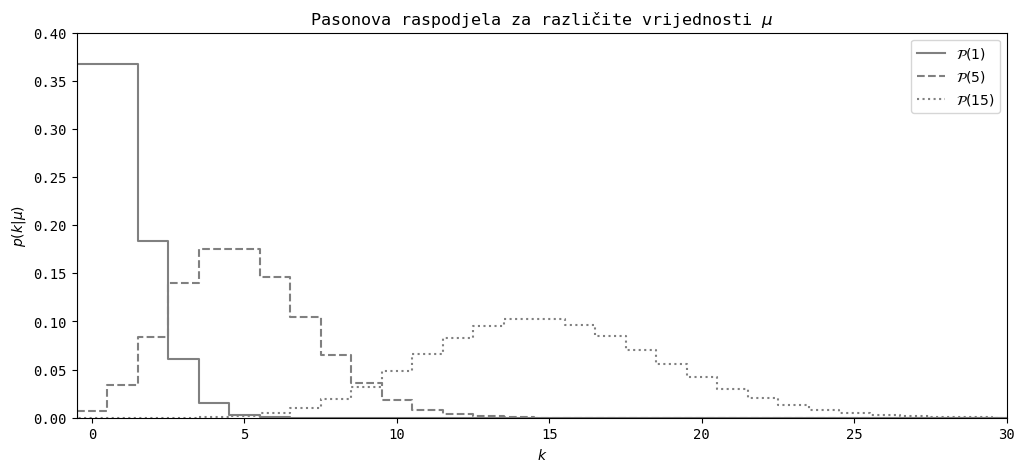

In [68]:
k = np.arange(-1, 200)
p1 = poisson(1)
p2 = poisson(5)
p3 = poisson(15)

plt.figure(figsize=(12, 5))
plt.plot(k, p1.pmf(k), label=r'$\mathcal{P}(1)$', color='grey', ls='-', drawstyle='steps-mid')
plt.plot(k, p2.pmf(k), label=r'$\mathcal{P}(5)$', color='grey', ls='--', drawstyle='steps-mid')
plt.plot(k, p3.pmf(k), label=r'$\mathcal{P}(15)$', color='grey', ls=':', drawstyle='steps-mid')
plt.xlim(-0.5, 30)
plt.ylim(0, 0.4)
plt.xlabel('$k$')
plt.ylabel(r'$p(k|\mu)$')
plt.title('Pasonova raspodjela za različite vrijednosti $\mu$')
plt.legend()
plt.show()  

$\bigstar$ ( v )  **Košijeva raspodjela (ili Lorencijan)** data je preko:

$$
p(x\,|\,\mu,\gamma)=\frac{1}{\pi\gamma}\Big(\frac{\gamma^2}{\gamma^2+(x-\mu)^2}\Big).
$$

Medijana i moda su jednake parametru lokacije $\mu$, a $\gamma$ je parametar skaliranja. Za veliko $|x|$, repovi raspodjele opadaju kao $x^{-2}$, te ova raspodjela *nema*

srednju vrijednost, varijansu, standardnu devijaciju i više momente. Ukoliko je dat skup $\{x_i\}$ uzorkovan iz Košijeve raspodjele, parametri lokacije i skale

ne mogu biti određeni izračunavanjem srednje vrijednosti i standardne devijacije preko klasičnih formula. Može se izračunati srednja vrijednost za $\{x_i\}$,

 ali će ona imati veliko raspršenje oko $\mu$ (koje se ne smanjuje povećanjem broja uzoraka). Raspodjela srednjih vrijednosti za mnogo nezavisnih uzoraka će

biti Košijeva. Ipak, $\mu$ se može odrediti preko medijane $\{x_i\}$ , a $\gamma$ preko interkvartilnog opsjega (koji je ovdje jednak $2\gamma$).

Odnos dvije nezavisne standardne normalne varijable $x_1,x_2\sim\mathcal{N}(0,1)$ dat kao $z=x_1/x_2$, će pratiti Košijevu raspodjelu sa $\mu=0$ i $\gamma=1$. Za neki

generalniji slučaj, odnos $z=\mathcal{N}(\mu_2,\sigma_2)/\mathcal{N}(\mu_1,\sigma_1)$ prati kompleksniju (tzv. Hinklijevu) raspodjelu.

In [206]:
dist = cauchy(0, 1) 
r = dist.rvs(10) 
print(r)
p = dist.pdf(3)
print(p)

[-0.45745277  2.67186322  0.48050125  0.13432594 -0.63577029 -1.6378915
 -0.02468114  1.57836122 -0.99127044  2.39076037]
0.03183098861837907


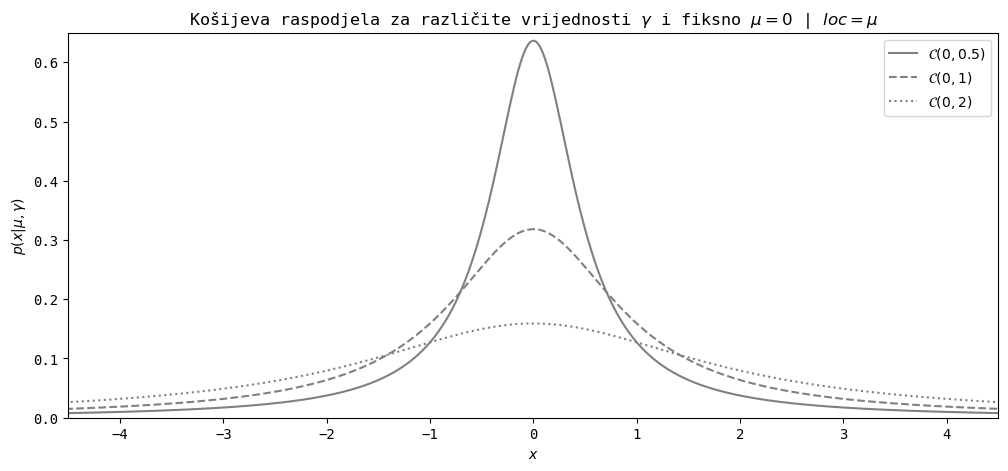

In [72]:
x = np.linspace(-10, 10, 1000)
c1 = cauchy(0, 0.5)
c2 = cauchy(0, 1)
c3 = cauchy(0, 2)

plt.figure(figsize=(12, 5))
plt.plot(x, c1.pdf(x), label=r'$\mathcal{C}(0, 0.5)$', color='grey', ls='-')
plt.plot(x, c2.pdf(x), label=r'$\mathcal{C}(0, 1)$', color='grey', ls='--')
plt.plot(x, c3.pdf(x), label=r'$\mathcal{C}(0, 2)$', color='grey', ls=':')
plt.xlim(-4.5, 4.5)
plt.ylim(0, 0.65)
plt.xlabel('$x$')
plt.ylabel(r'$p(x|\mu,\gamma)$')
plt.title('Košijeva raspodjela za različite vrijednosti $\gamma$ i fiksno $\mu=0$ | $loc=\mu$')
plt.legend()
plt.show()  

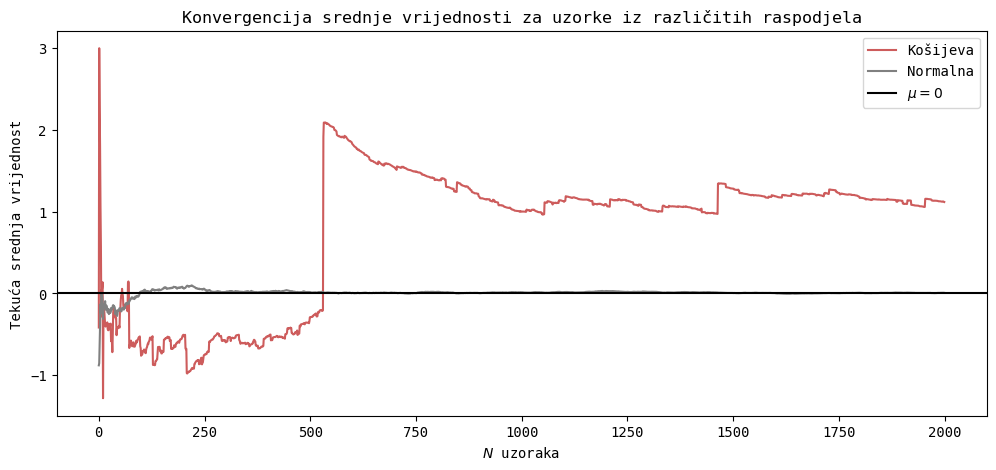

In [217]:
np.random.seed(42)
N = 2000

kosi_uzorci = cauchy(0, 1).rvs(N)
gaus_uzorci = norm(0, 1).rvs(N)

tekuca_sv_kosi = np.cumsum(kosi_uzorci) / np.arange(1, N+1)
tekuca_sv_gaus = np.cumsum(gaus_uzorci) / np.arange(1, N+1)

plt.figure(figsize=(12, 5))
plt.plot(tekuca_sv_kosi, color='indianred', label='Košijeva')
plt.plot(tekuca_sv_gaus, color='grey', label='Normalna')
plt.axhline(0, color='black', ls='-', label=r'$\mu=0$')
plt.xlabel(r'$N$ uzoraka')
plt.ylabel('Tekuća srednja vrijednost')
plt.title('Konvergencija srednje vrijednosti za uzorke iz različitih raspodjela')
plt.legend()
plt.show()

$\bigstar$ ( vi )  **Laplasova raspodjela**  data je kao:

$$
p(x\,|\,\mu,\Delta)=\frac{1}{2\Delta}e^{\frac{-|x-\mu|}{\Delta}}.
$$

U slučaju da je $x>0$ gornja raspodjela se naziva *jednostrana eksponencijalna* (generalno je *dupla eksponencijalna* - Laplasova). Desna strana Laplasove

raspodjele je sličnog oblika eksponencijalnoj, ali imaju različite normalizacije:

$$
\int_0^{\infty} p_{\mathcal{L}}(x\,|\,\mu, \Delta)\, dx = \frac{1}{2},\,\,\int_0^{\infty} p_{\mathcal{E}}(x\,|\,\lambda)\, dx = 1.
$$

Najjednostavniji slučaj *jednostrane* eksponencijalne raspodjele je $p(x\,|\,\tau)=\tau^{-1}e^{-x/\tau}$, gdje su očekivana vrijednost i standardna devijacije jednake $\tau$.

Ova raspodjela opisuje vrijeme između dva nezavisna uzastopna događaja (sa konstantnim vremenskim razmakom) - npr. fotoni koji *dolaze* na detektor.

Laplasijan je simetričan oko $\mu$, te su srednja vrijednost, medijana i mod jednaki $\mu$, a asimetričnost je nula. Standardna devijacija je data kao $\sigma=\sqrt{2\sigma}$. 

Za normalnu raspodjelu, $|x_i-\mu|>5\sigma$ *dešava* se rjeđe nego jednom u milion, za eksponencijalnu raspodjelu se *dešava* jedanput u hiljadu slučajeva.

In [212]:
dist = laplace(0, 0.5) 
r = dist.rvs(10)
print(r)
p = dist.pdf(3)
print(p)

[-0.3177177  -0.6695966  -0.26427035 -0.32347244  0.16108352  1.19840424
  0.23219965  0.95967876  0.41997109  0.30417811]
0.0024787521766663585


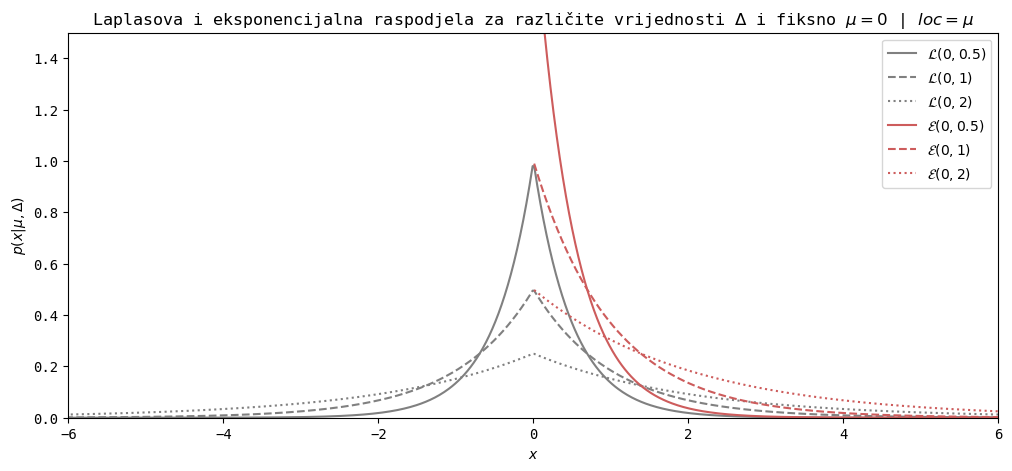

In [93]:
x = np.linspace(-10, 10, 1000)
xe = np.linspace(0, 10, 1000)[1:] # eksponencijalna raspodjela
l1 = laplace(0, 0.5)
l2 = laplace(0, 1)
l3 = laplace(0, 2)
e1 = expon(0, 0.5)
e2 = expon(0, 1)
e3 = expon(0, 2)

plt.figure(figsize=(12, 5))
plt.plot(x, l1.pdf(x), label=r'$\mathcal{L}(0, 0.5)$', color='grey', ls='-')
plt.plot(x, l2.pdf(x), label=r'$\mathcal{L}(0, 1)$', color='grey', ls='--')
plt.plot(x, l3.pdf(x), label=r'$\mathcal{L}(0, 2)$', color='grey', ls=':')
plt.plot(xe, e1.pdf(xe), label=r'$\mathcal{E}(0, 0.5)$', color='indianred', ls='-')
plt.plot(xe, e2.pdf(xe), label=r'$\mathcal{E}(0, 1)$', color='indianred', ls='--')
plt.plot(xe, e3.pdf(xe), label=r'$\mathcal{E}(0, 2)$', color='indianred', ls=':')

plt.xlim(-6, 6)
plt.ylim(0, 1.5)
plt.xlabel('$x$')
plt.ylabel(r'$p(x|\mu,\Delta)$')
plt.title('Laplasova i eksponencijalna raspodjela za različite vrijednosti $\Delta$ i fiksno $\mu=0$ | $loc=\mu$')
plt.legend()
plt.show()  

$\bigstar$ ( vii )  **Gama ($\Gamma$) raspodjela** ima sljedeći oblik:

$$
p(x\,|\,k, \theta) = \frac{1}{\theta^k} \frac{x^{k-1} e^{-x/\theta}}{\Gamma(k)},\,\,0<x<\infty,
$$

gdje su $k$ parametar oblika i $\theta$ parametar skale. Dakle, Gama raspodjela nije isto što i Gama funkcija:

$$
\Gamma(k) = \int_0^{\infty} x^{k-1} e^{-x}dx,\,\,\Gamma(k) = (k-1)!
$$

Gama raspodjela je izuzetno korisna u bajesovskoj statistici (npr. ukoliko je baš ona priorna, izbjegavaju se neki komplikovani integrali za dobijanje

 posteriorne raspodjele).


In [218]:
dist = gamma(1, 0, 2) # k, loc, theta
r = dist.rvs(10) 
print(r)
p = dist.pdf(1) 
print(p)

[1.82908096 1.44189143 0.67987313 0.01297068 1.37130754 0.67269726
 2.65309687 0.04847528 1.75812386 5.67657647]
0.3032653298563167


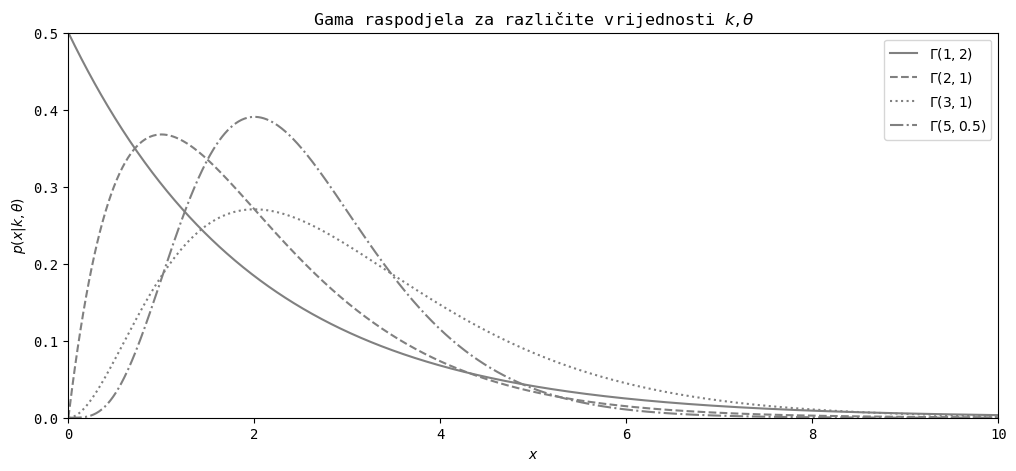

In [219]:
x = np.linspace(1e-6, 10, 1000)
g1 = gamma(1, 0, 2) 
g2 = gamma(2, 0, 1)
g3 = gamma(3, 0, 1)
g4 = gamma(5, 0, 0.5)

plt.figure(figsize=(12, 5))
plt.plot(x, g1.pdf(x), label=r'$\Gamma(1, 2)$', color='grey', ls='-')
plt.plot(x, g2.pdf(x), label=r'$\Gamma(2, 1)$', color='grey', ls='--')
plt.plot(x, g3.pdf(x), label=r'$\Gamma(3, 1)$', color='grey', ls=':')
plt.plot(x, g4.pdf(x), label=r'$\Gamma(5, 0.5)$', color='grey', ls='-.')
plt.xlim(0, 10)
plt.ylim(0, 0.5)
plt.xlabel('$x$')
plt.ylabel(r'$p(x|k,\theta)$')
plt.title(r'Gama raspodjela za različite vrijednosti $k,\theta$')
plt.legend()
plt.show()  

$\bigstar$ ( viii )  **Beta ($\beta$) raspodjela** je data preko:

$$
p(x\,|\,\alpha, \beta) = \frac{\Gamma(\alpha + \beta)}{\Gamma(\alpha)\Gamma(\beta)}\, x^{\alpha-1}(1-x)^{\beta-1},\,\,0<x<1,
$$

gdje su $\alpha$ i $\beta$ (pozitivni) parametri. Srednja vrijednost beta raspodjele je $\frac{\alpha}{\alpha+\beta}$. Takođe je korisna u bajesovskoj statistici.

In [220]:
dist = beta (0.5, 1.5) # alfa, beta
r = dist.rvs(10)
print(r)
p = dist.pdf(0.6)
print(p)

[2.07349619e-02 2.40067103e-01 4.77864709e-01 7.03181117e-02
 4.10777589e-01 1.34510055e-01 1.27450537e-01 2.40789988e-01
 7.00508238e-05 2.08092442e-04]
0.5197978674891173


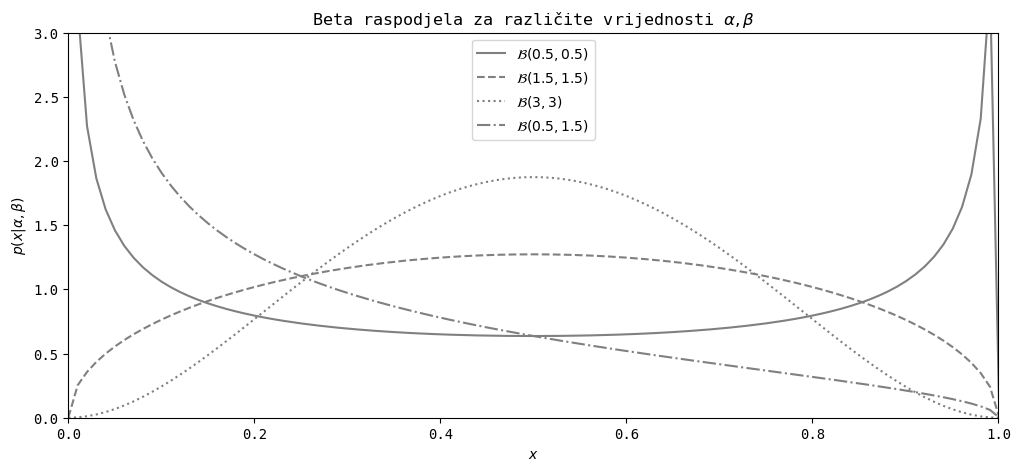

In [227]:
x = np.linspace(1e-6, 10, 1000)
beta1 = beta(0.5, 0.5) 
beta2 = beta(1.5, 1.5)
beta3 = beta(3, 3)
beta4 = beta(0.5, 1.5)

plt.figure(figsize=(12, 5))
plt.plot(x, beta1.pdf(x), label=r'$\mathcal{B}(0.5, 0.5)$', color='grey', ls='-')
plt.plot(x, beta2.pdf(x), label=r'$\mathcal{B}(1.5, 1.5)$', color='grey', ls='--')
plt.plot(x, beta3.pdf(x), label=r'$\mathcal{B}(3, 3)$', color='grey', ls=':')
plt.plot(x, beta4.pdf(x), label=r'$\mathcal{B}(0.5, 1.5)$', color='grey', ls='-.')
plt.xlim(0, 1)
plt.ylim(0, 3)
plt.xlabel('$x$')
plt.ylabel(r'$p(x|\alpha,\beta)$')
plt.title(r'Beta raspodjela za različite vrijednosti $\alpha,\beta$')
plt.legend()
plt.show()  

$\bigstar$ (ix) **Studentova t raspodjela** data je jednačinom:

$$
p(x\,|\,k)= \frac{\Gamma\!\left(\frac{k+1}{2}\right)}{\sqrt{\pi k}\,\Gamma\!\left(\frac{k}{2}\right)} \left(1 + \frac{x^2}{k}\right)^{-\frac{k+1}{2}},
$$

gdje je $k$ broj stepeni slobode. Kriva je slična Gausovoj raspodjeli, ali ima deblje repove. Srednja vrijednost, medijana i mod su nulti za $k>1$ i nedefinisani

su za $k=1$ - za ovu vrijednost $k$ Studentova t raspodjela se pretvara u Košijevu $p(x)=\pi^{-1}(1+x^2)^{-1}$. Za $k>2$, standardna devijacija je $\sqrt{\frac{k}{k-2}}$, za 

$k>3$ koeficijent asimetrije je nula, a za $k>4$ kurtosis je $\frac{6}{k-4}$. Za veliko $k$, Studentova t raspodjela teži $\mathcal{N}(0,1)$. Ukoliko postoji uzorak od $N$ mjerenja

$\{x_i\}$ izvučenih iz $\mathcal{N}(\mu,\sigma)$, onda varijabla:

$$
t=\frac{\overline{x}-\mu}{s/\sqrt{N}},
$$

gdje su $\overline{x}$ aritmetička srednja vrijednost uzorka i $s$ standardna devijacija uzorka, prati Studentovu t raspodjelu sa $k=N-1$ stepeni slobode. 

In [224]:
dist = student_t(5) 
r = dist.rvs(10) 
print(r)
p = dist.pdf(3)
print(p)

[ 0.97313954  0.04357159  2.92904794 -0.96282905  0.80845351  1.86125998
 -0.32285324 -2.55533832 -1.07615697  1.31742577]
0.01729257880022295


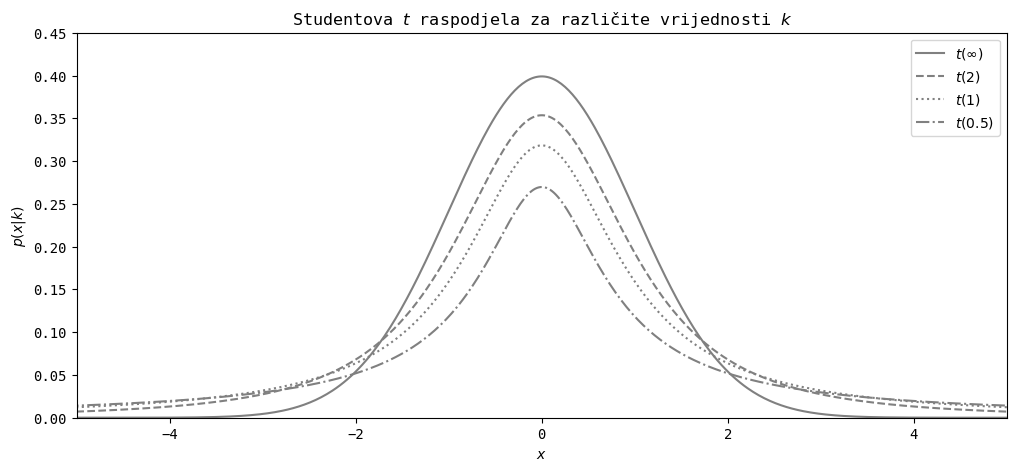

In [115]:
x = np.linspace(-10, 10, 1000)
student_t1 = student_t(1e10, 0)
student_t2 = student_t(2, 0)
student_t3 = student_t(1, 0)
student_t4 = student_t(0.5, 0)

plt.figure(figsize=(12, 5))
plt.plot(x, student_t1.pdf(x), label=r'$t(\infty)$', color='grey', ls='-')
plt.plot(x, student_t2.pdf(x), label=r'$t(2)$', color='grey', ls='--')
plt.plot(x, student_t3.pdf(x), label=r'$t(1)$', color='grey', ls=':')
plt.plot(x, student_t4.pdf(x), label=r'$t(0.5)$', color='grey', ls='-.')
plt.xlim(-5, 5)
plt.ylim(0.0, 0.45)
plt.xlabel('$x$')
plt.ylabel(r'$p(x|k)$')
plt.title(r'Studentova $t$ raspodjela za različite vrijednosti $k$')
plt.legend()
plt.show()  

$\bigstar$ (x) **Fišerova F raspodjela** prikazuje se jednačinom:

$$
p(x\,|\,d_1, d_2) = C\left(1 + \frac{d_1}{d_2}x\right)^{-\frac{d_1+d_2}{2}} x^{\frac{d_1}{2}-1},\,\,x\geq0,\,d_1>0,\,d_2>0,
$$

gdje su $d_1$ i $d_2$ stepeni slobode, a $C$ konstanta normalizacije data kao:

$$
C = \frac{1}{\mathcal{B}(d_1/2,\, d_2/2)} \left(\frac{d_1}{d_2}\right)^{d_1/2},
$$

gdje figuriše $\mathcal{B}$, tj. beta funkcija. Kada su $d_1$ i $d_2$ neke velike vrijednosti, srednja vrijednost je $\frac{d_2}{d_2-2}\approx1$, a standardna devijacija je $\sigma=\sqrt{2\frac{d_1+d_2}{d_1d_2}}$. Ako su

npr. $x_1$ i $x_2$ dvije nezavisne slučajne varijable izvučene iz Košijeve raspodjele (sa parametrom lokacije $\mu$), onda odnos $\frac{|x_1-\mu|}{|x_2-\mu|}$ prati Fišerovu 
F raspodjelu

 sa $d_1=d_2=2$.

In [225]:
dist = fisher_f(2, 3) # d1, d2
r = dist.rvs(10)
print(r) 
p = dist.pdf(1)
print(p) 

[0.82284301 2.58069773 0.10821549 0.16295295 2.35475355 1.32755173
 1.90874665 2.3966009  0.90720708 0.10169556]
0.27885480092693415


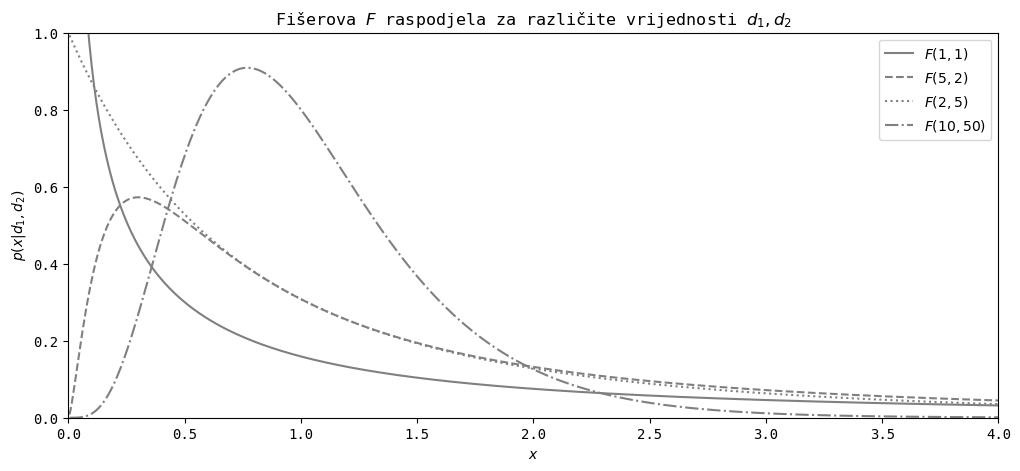

In [121]:
x = np.linspace(0, 5, 1001)[1:]
fiser_f1 = fisher_f(1, 1, 0)
fiser_f2 = fisher_f(5, 2, 0)
fiser_f3 = fisher_f(2, 5, 0)
fiser_f4 = fisher_f(10, 50, 0)

plt.figure(figsize=(12, 5))
plt.plot(x, fiser_f1.pdf(x), label=r'$F(1,1)$', color='grey', ls='-')
plt.plot(x, fiser_f2.pdf(x), label=r'$F(5,2)$', color='grey', ls='--')
plt.plot(x, fiser_f3.pdf(x), label=r'$F(2,5)$', color='grey', ls=':')
plt.plot(x, fiser_f4.pdf(x), label=r'$F(10,50)$', color='grey', ls='-.')
plt.xlim(0, 4)
plt.ylim(0.0, 1.0)
plt.xlabel('$x$')
plt.ylabel(r'$p(x|d_1, d_2)$')
plt.title(r'Fišerova $F$ raspodjela za različite vrijednosti $d_1, d_2$')
plt.legend()
plt.show()  

$\bigstar$ ( xi )  **$\chi^2$ raspodjela** je jedna od najvažnijih raspodjela u statistici. Ako je skup $\{x_i\}$ uzorkovan iz normalne raspodjele, i ako se definiše $z_i=\frac{x_i-\mu}{\sigma}$,

onda suma kvadrata $Q=\sum_{i=1}^Nz_i^2$ prati baš $\chi^2$ raspodjelu sa $k=N$ stepeni slobode:

$$
p(Q|k) \equiv \chi^2(Q\,|\,k) = \frac{1}{2^{k/2}\,\Gamma(k/2)}\, Q^{k/2-1} e^{\frac{-Q}{2}},\,Q>0,
$$

gdje $k$ označava broj stepeni slobode. Raspodjela vrijednosti $Q$ zavisi samo od veličine uzorka, a ne od vrijednosti $\mu$ i $\sigma$. Ukoliko je slučaj da je $\mu=0$ 

i $\sigma=1$, onda je $\chi^2$ suma standardizovanih gausijana. Može se definisati $\chi^2$ po stepenu slobode:

$$
\chi^2_{dof}(Q\,|\,k) \equiv \chi^2(Q/k\,|\,k).
$$

Srednja vrijednost $\chi^2_{dof}$ je 1, a standardna devijacija $\sqrt{2/k}$. Medijana je otprilike $(1-\frac{2}{9k})^3$. Koeficijent asimetrije za $\chi^2_{dof}$ je $\sqrt{8/k}$, a kurtosis $12/k$.

Sa povećavanjem $k$, $\chi^2_{dof}$ teži u $\mathcal{N}(1,\sqrt{2/k})$. Suma $Q$ je jako osjetljiva na odstupajuće vrijednosti. Lorisno je napraviti poređenje između Studentove

t raspodjele i $\chi^2$ raspodjele. Dakle, $t$ definisano u Studentovoj t raspodjeli je donekle slično kao $Q$ koje smo definisali ovdje. Razlika je u tome što je $t$

dato preko procjena iz podataka $\overline{x}$ i $s$, a $\chi^2$ statistika je bazirana na pravim vrijednostima $\mu$ i $\sigma$. Takođe, odnos standardne normalne varijable i varijable 

izvučene iz $\chi^2$ raspodjele prati Studentovu t raspodjelu. Dodatno, Fišerova F raspodjela opisuje raspodjelu odnosa dvije nezavisne varijable $\chi^2_{dof}$ sa $d_1$

 i $d_2$ stepeni slobode. 



In [228]:
dist = chi2(5) # k
r = dist.rvs(10)
print(r) 
p = dist.pdf(1) 
print(p)

[ 8.87357159  4.09151727  4.88097135  9.0528223  16.53939215  5.16048217
  6.10078385  7.30423692  8.99990833  8.25098386]
0.0806569081730478


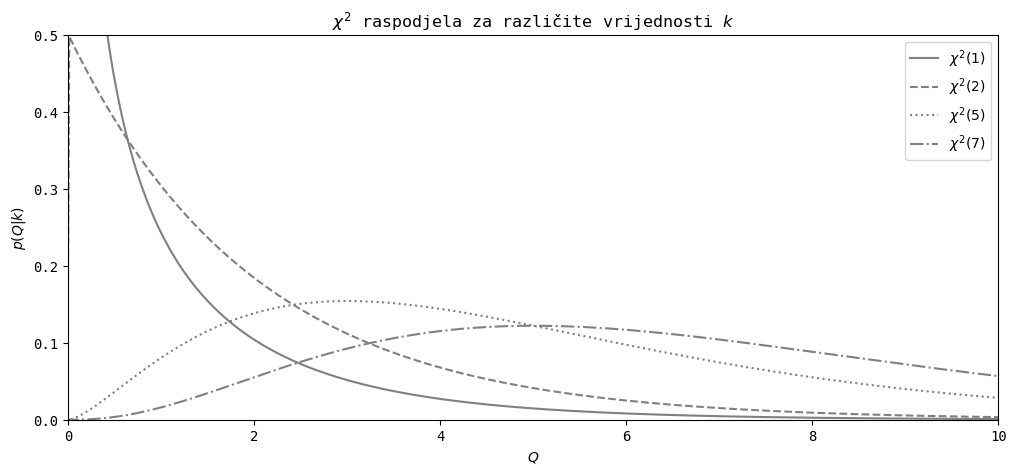

In [229]:
x = np.linspace(-1, 20, 1000)
chi2_1 = chi2(1, 0)
chi2_2 = chi2(2, 0)
chi2_3 = chi2(5, 0)
chi2_4 = chi2(7, 0)

plt.figure(figsize=(12, 5))
plt.plot(x, chi2_1.pdf(x), label=r'$\chi^2(1)$', color='grey', ls='-')
plt.plot(x, chi2_2.pdf(x), label=r'$\chi^2(2)$', color='grey', ls='--')
plt.plot(x, chi2_3.pdf(x), label=r'$\chi^2(5)$', color='grey', ls=':')
plt.plot(x, chi2_4.pdf(x), label=r'$\chi^2(7)$', color='grey', ls='-.')
plt.xlim(0, 10)
plt.ylim(0, 0.5)
plt.xlabel('$Q$')
plt.ylabel(r'$p(Q|k)$')
plt.title(r'$\chi^2$ raspodjela za različite vrijednosti $k$')
plt.legend()
plt.show()  

$\bigstar$ ( xii )  **Vejbulova raspodjela** ima sljedeći oblik:

$$
p(x\,|\,k, \lambda) = \frac{k}{\lambda}\left(\frac{x}{\lambda}\right)^{k-1} e^{-(x/\lambda)^k},\,\,x\geq0,
$$

gdje je $\lambda$ parametar skale, a $k$ parametar oblika. Srednja vrijednost je data kao $\lambda\Gamma(1+1/k)$, a medijana preko $\lambda(\ln2)^{1/k}$. Parametar $k$ može biti

iskorišćen za interpolaciju između eksponencijalne raspodjele ($k=1$) i Rejlijeve raspodjele ($k=2$). Kako $k\rightarrow\infty$, tako se Vejbulova raspodjela

transformiše u Dirakovu $\delta$-funkciju. Ukoliko npr. $x$ prati uniformnu raspodjelu na $(0,1)$, onda slučajna varijabla $y=\lambda(-\ln{x})^{1/k}$ prati Vejbulovu

raspodjelu. Adekvatniji primjer bi bio sljedeći: ako je $x$ vrijeme do otkaza naprave, gdje je stopa otkaza proporcionalna stepenu vremena $t^m$, onda

$x$ prati Vejbulovu raspodjelu sa $k=m+1$. Ova raspodjela se često sreće u inženjerstvu i mnogim granama fizike.

In [230]:
dist = weibull_min(1, 0, 2) # k, loc, lambda 
r = dist.rvs(10)
print(r)
p = dist.pdf(1)
print(p) 

[2.58467274 0.23889739 1.04774754 4.34979784 0.0966936  6.50986731
 2.27364146 1.99595613 0.63095429 0.57214484]
0.3032653298563167


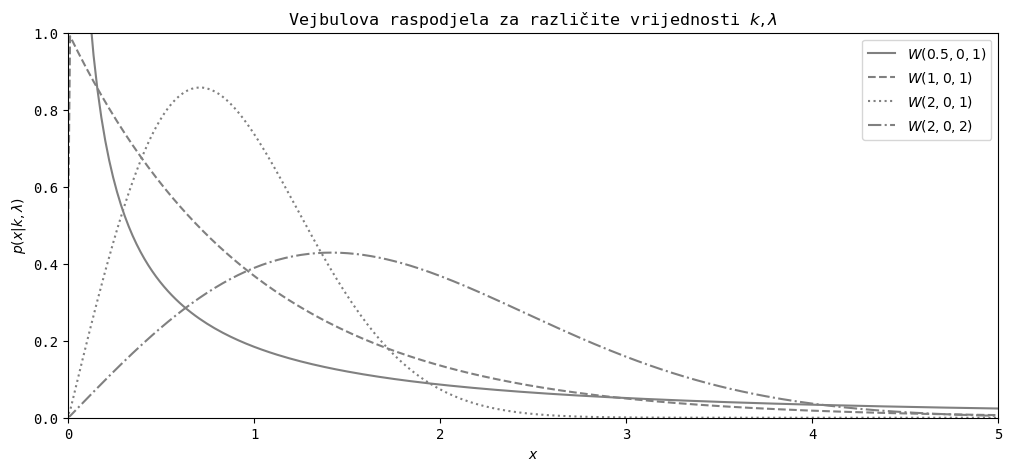

In [128]:
x = np.linspace(-1, 20, 1000)
w1 = weibull_min(0.5, 0, 1)
w2 = weibull_min(1, 0, 1)
w3 = weibull_min(2, 0, 1)
w4 = weibull_min(2, 0, 2)

plt.figure(figsize=(12, 5))
plt.plot(x, w1.pdf(x), label=r'$W(0.5, 0, 1)$', color='grey', ls='-')
plt.plot(x, w2.pdf(x), label=r'$W(1, 0, 1)$', color='grey', ls='--')
plt.plot(x, w3.pdf(x), label=r'$W(2, 0, 1)$', color='grey', ls=':')
plt.plot(x, w4.pdf(x), label=r'$W(2, 0, 2)$', color='grey', ls='-.')
plt.xlim(0, 5)
plt.ylim(0, 1)
plt.xlabel('$x$')
plt.ylabel(r'$p(x|k,\lambda)$')
plt.title('Vejbulova raspodjela za različite vrijednosti $k,\lambda$')
plt.legend()
plt.show()

---

